# Day 08｜From nodes to paths: Path and Edge Attribution Patching

We use **Qwen2.5-0.5B**, **TransformerLens**, true component-level activation patching, a real sender → receiver **Path Patching** intervention, and **Edge Attribution Patching (EAP)**. The experiment continues Day 7's `Japan → Tokyo` versus `Taiwan → Taipei` setup.

## 1. Setup

In [1]:
%env PIP_DISABLE_PIP_VERSION_CHECK=1
%pip install -q "transformer-lens==2.18.0" "transformers==4.57.6" "matplotlib==3.10.8"


env: PIP_DISABLE_PIP_VERSION_CHECK=1


Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from transformer_lens import HookedTransformer

MODEL_NAME = "Qwen/Qwen2.5-0.5B"
CLEAN_PROMPT = "The capital of Japan is"
CORRUPTED_PROMPT = "The capital of Taiwan is"
CLEAN_ANSWER = " Tokyo"
CORRUPTED_ANSWER = " Taipei"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## 2. Load Qwen2.5-0.5B

In [3]:
print("Loading Qwen2.5-0.5B with TransformerLens...")
model = HookedTransformer.from_pretrained(MODEL_NAME, device=device)
model.set_ungroup_grouped_query_attention(True)
model.set_use_split_qkv_input(True)
model.eval()
model.zero_grad(set_to_none=True)

print(f"Model: {MODEL_NAME}")
print(f"Transformer blocks: {model.cfg.n_layers}")
print(f"Attention heads per block: {model.cfg.n_heads}")
print(f"Residual-stream width: {model.cfg.d_model}")
print("Split Q/K/V inputs are enabled so we can score sender → receiver edges.")
print("Gradients are enabled for attribution; no optimizer updates the model weights.")

Loading Qwen2.5-0.5B with TransformerLens...


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model Qwen/Qwen2.5-0.5B into HookedTransformer
Model: Qwen/Qwen2.5-0.5B
Transformer blocks: 24
Attention heads per block: 14
Residual-stream width: 896
Split Q/K/V inputs are enabled so we can score sender → receiver edges.
Gradients are enabled for attribution; no optimizer updates the model weights.


## 3. Reproduce the Day 7 behavior

```text
Clean:     The capital of Japan  is → Tokyo
Corrupted: The capital of Taiwan is → Taipei
```

We keep the same metric:

```text
logit(" Tokyo") − logit(" Taipei")
```

Positive values favor the clean answer; negative values favor the corrupted answer.

In [4]:
clean_tokens = model.to_tokens(CLEAN_PROMPT)
corrupted_tokens = model.to_tokens(CORRUPTED_PROMPT)
assert clean_tokens.shape == corrupted_tokens.shape

clean_str_tokens = model.to_str_tokens(clean_tokens[0])
corrupted_str_tokens = model.to_str_tokens(corrupted_tokens[0])

clean_answer_id = model.to_single_token(CLEAN_ANSWER)
corrupted_answer_id = model.to_single_token(CORRUPTED_ANSWER)


def metric_tensor(logits):
    return logits[0, -1, clean_answer_id] - logits[0, -1, corrupted_answer_id]


COUNTRY_POSITION = clean_str_tokens.index(" Japan")
FINAL_POSITION = clean_tokens.shape[1] - 1

token_table = pd.DataFrame(
    {
        "Position": np.arange(clean_tokens.shape[1]),
        "Clean token": clean_str_tokens,
        "Corrupted token": corrupted_str_tokens,
        "Changed?": [a != b for a, b in zip(clean_str_tokens, corrupted_str_tokens)],
    }
)
display(token_table)

,Position,Clean token,Corrupted token,Changed?
0,0,The,The,False
1,1,capital,capital,False
2,2,of,of,False
3,3,Japan,Taiwan,True
4,4,is,is,False


In [5]:
with torch.inference_mode():
    clean_logits = model(clean_tokens)
    corrupted_logits = model(corrupted_tokens)

clean_metric = metric_tensor(clean_logits).item()
corrupted_metric = metric_tensor(corrupted_logits).item()
metric_gap = clean_metric - corrupted_metric

baseline = pd.DataFrame(
    [
        {"Run": "Clean", "Tokyo − Taipei logit difference": clean_metric},
        {"Run": "Corrupted", "Tokyo − Taipei logit difference": corrupted_metric},
    ]
)
display(baseline.round(3))
print(f"Clean–corrupted metric gap: {metric_gap:.3f}")

,Run,Tokyo − Taipei logit difference
0,Clean,7.472
1,Corrupted,-5.640


Clean–corrupted metric gap: 13.112


## 4. Use node search to choose path endpoints

Path Patching needs a sender and a receiver. We first use ordinary component-level patching to find plausible endpoints, breaking Day 7's residual-stream sites into smaller nodes:

- each attention head's `z` output;
- each MLP output;
- at the changed country position and the final prediction position.

For Qwen2.5-0.5B this gives:

```text
24 layers × (14 heads + 1 MLP) × 2 positions = 720 candidates
```

These are **component-level nodes**, not isolated edges. This sweep only proposes sender and receiver candidates; the next experiment controls how a selected sender difference reaches a selected downstream receiver.

In [6]:
n_layers = model.cfg.n_layers
n_heads = model.cfg.n_heads
candidate_positions = [COUNTRY_POSITION, FINAL_POSITION]

candidate_hook_names = {
    hook_name
    for layer in range(n_layers)
    for hook_name in (
        f"blocks.{layer}.attn.hook_z",
        f"blocks.{layer}.hook_mlp_out",
    )
}


def is_candidate_hook(name):
    return name in candidate_hook_names


candidates = []
candidate_id = 0
for layer in range(n_layers):
    for position in candidate_positions:
        for head in range(n_heads):
            candidates.append(
                {
                    "Candidate id": candidate_id,
                    "Component": "Attention head",
                    "Layer": layer,
                    "Position": position,
                    "Head": head,
                    "Hook name": f"blocks.{layer}.attn.hook_z",
                    "Label": f"L{layer}H{head} @ {position}:{corrupted_str_tokens[position]!r}",
                }
            )
            candidate_id += 1
        candidates.append(
            {
                "Candidate id": candidate_id,
                "Component": "MLP",
                "Layer": layer,
                "Position": position,
                "Head": None,
                "Hook name": f"blocks.{layer}.hook_mlp_out",
                "Label": f"MLP L{layer} @ {position}:{corrupted_str_tokens[position]!r}",
            }
        )
        candidate_id += 1

print(f"Candidate count: {len(candidates)}")
print(
    "Positions:",
    [(position, corrupted_str_tokens[position]) for position in candidate_positions],
)

Candidate count: 720
Positions: [(3, ' Taiwan'), (4, ' is')]


## 5. Locate sender and receiver candidates with node patching

For each candidate, we really replace its corrupted activation with the clean activation and rerun the model. We report normalized restoration:

\[
\frac{M_{\text{patched}}-M_{\text{corrupted}}}
     {M_{\text{clean}}-M_{\text{corrupted}}}
\]

This is a node-localization step inherited from Day 7. It is not yet Path Patching.

In [7]:
with torch.inference_mode():
    _, clean_cache = model.run_with_cache(
        clean_tokens,
        names_filter=is_candidate_hook,
    )


def run_component_patch(candidate):
    hook_name = candidate["Hook name"]
    position = candidate["Position"]

    if candidate["Component"] == "Attention head":
        head = candidate["Head"]

        def patch_hook(activation, hook):
            activation[:, position, head, :] = clean_cache[hook_name][
                :, position, head, :
            ]
            return activation

    else:

        def patch_hook(activation, hook):
            activation[:, position, :] = clean_cache[hook_name][:, position, :]
            return activation

    with torch.inference_mode():
        return model.run_with_hooks(
            corrupted_tokens,
            fwd_hooks=[(hook_name, patch_hook)],
        )


true_start = time.perf_counter()
true_rows = []
for candidate in candidates:
    patched_logits = run_component_patch(candidate)
    patched_metric = metric_tensor(patched_logits).item()
    true_effect = patched_metric - corrupted_metric
    true_rows.append(
        {
            "Candidate id": candidate["Candidate id"],
            "True patch effect": true_effect,
            "True restoration": true_effect / metric_gap,
        }
    )

true_patch_seconds = time.perf_counter() - true_start
true_df = pd.DataFrame(true_rows)
candidate_df = pd.DataFrame(candidates)
true_df = candidate_df.merge(true_df, on="Candidate id")

print(f"Completed {len(candidates)} true interventions in {true_patch_seconds:.1f} seconds.")
display(
    true_df.sort_values("True restoration", ascending=False)[
        ["Label", "Component", "True patch effect", "True restoration"]
    ]
    .head(15)
    .round(3)
)

Completed 720 true interventions in 58.5 seconds.


,Label,Component,True patch effect,True restoration
14,MLP L0 @ 3:' Taiwan',MLP,13.176,1.005
651,L21H6 @ 4:' is',Attention head,7.815,0.596
134,MLP L4 @ 3:' Taiwan',MLP,3.401,0.259
659,MLP L21 @ 4:' is',MLP,2.972,0.227
646,L21H1 @ 4:' is',Attention head,1.950,0.149
494,MLP L16 @ 3:' Taiwan',MLP,1.707,0.130
620,L20H5 @ 4:' is',Attention head,1.531,0.117
299,MLP L9 @ 4:' is',MLP,1.039,0.079
621,L20H6 @ 4:' is',Attention head,0.663,0.051
527,L17H2 @ 4:' is',Attention head,0.633,0.048


## 6. Test one sender → receiver path

The component sweep identifies important **nodes**, but it does not tell us how they interact. We now test one concrete path:

```text
upstream sender at the country token
                ↓
downstream attention head at the final token
                ↓
              output
```

We choose the strongest upstream MLP and strongest downstream attention head from the true intervention sweep. To isolate their direct sender → receiver connection, we:

1. run the corrupted prompt;
2. patch the sender with its clean activation;
3. freeze every other attention/MLP output between sender and receiver to its corrupted value;
4. record the receiver activation produced by that isolated difference;
5. patch only that receiver activation into a fresh corrupted run and measure the output.

This tests one specified route. It does **not** claim that the two nodes form the model's complete circuit.

In [8]:
with torch.inference_mode():
    _, corrupted_component_cache = model.run_with_cache(
        corrupted_tokens,
        names_filter=is_candidate_hook,
    )

sender = (
    true_df[
        (true_df["Component"] == "MLP")
        & (true_df["Position"] == COUNTRY_POSITION)
        & (true_df["Layer"] < n_layers // 2)
    ]
    .sort_values("True restoration", ascending=False)
    .iloc[0]
)
sender_layer = int(sender["Layer"])
sender_hook = sender["Hook name"]

receiver = (
    true_df[
        (true_df["Component"] == "Attention head")
        & (true_df["Position"] == FINAL_POSITION)
        & (true_df["Layer"] > sender_layer)
    ]
    .sort_values("True restoration", ascending=False)
    .iloc[0]
)
receiver_layer = int(receiver["Layer"])
receiver_head = int(receiver["Head"])
receiver_hook = receiver["Hook name"]


def hook_layer(hook_name):
    return int(hook_name.split(".")[1])


freeze_hook_names = sorted(
    name
    for name in candidate_hook_names
    if sender_layer < hook_layer(name) < receiver_layer
)
receiver_from_sender = {}


def patch_sender(activation, hook):
    activation[:, COUNTRY_POSITION, :] = clean_cache[sender_hook][
        :, COUNTRY_POSITION, :
    ]
    return activation


def freeze_to_corrupted(activation, hook):
    return corrupted_component_cache[hook.name]


def capture_receiver(activation, hook):
    receiver_from_sender["activation"] = activation[
        :, FINAL_POSITION, receiver_head, :
    ].detach().clone()
    return activation


path_hooks = [(sender_hook, patch_sender)]
path_hooks += [(name, freeze_to_corrupted) for name in freeze_hook_names]
path_hooks += [(receiver_hook, capture_receiver)]

with torch.inference_mode():
    model.run_with_hooks(corrupted_tokens, fwd_hooks=path_hooks)


def patch_isolated_receiver(activation, hook):
    activation[:, FINAL_POSITION, receiver_head, :] = receiver_from_sender[
        "activation"
    ]
    return activation


with torch.inference_mode():
    path_logits = model.run_with_hooks(
        corrupted_tokens,
        fwd_hooks=[(receiver_hook, patch_isolated_receiver)],
    )

path_metric = metric_tensor(path_logits).item()
path_effect = path_metric - corrupted_metric
path_restoration = path_effect / metric_gap

path_results = pd.DataFrame(
    [
        {
            "Intervention": "Patch sender normally",
            "Normalized restoration": sender["True restoration"],
        },
        {
            "Intervention": "Patch receiver normally",
            "Normalized restoration": receiver["True restoration"],
        },
        {
            "Intervention": "Isolated sender → receiver path",
            "Normalized restoration": path_restoration,
        },
    ]
)

print(f"Sender:   {sender['Label']}")
print(f"Receiver: {receiver['Label']}")
print(f"Frozen intermediate component outputs: {len(freeze_hook_names)}")
display(path_results.round(3))

Sender:   MLP L0 @ 3:' Taiwan'
Receiver: L21H6 @ 4:' is'
Frozen intermediate component outputs: 40


,Intervention,Normalized restoration
0,Patch sender normally,1.005
1,Patch receiver normally,0.596
2,Isolated sender → receiver path,0.195


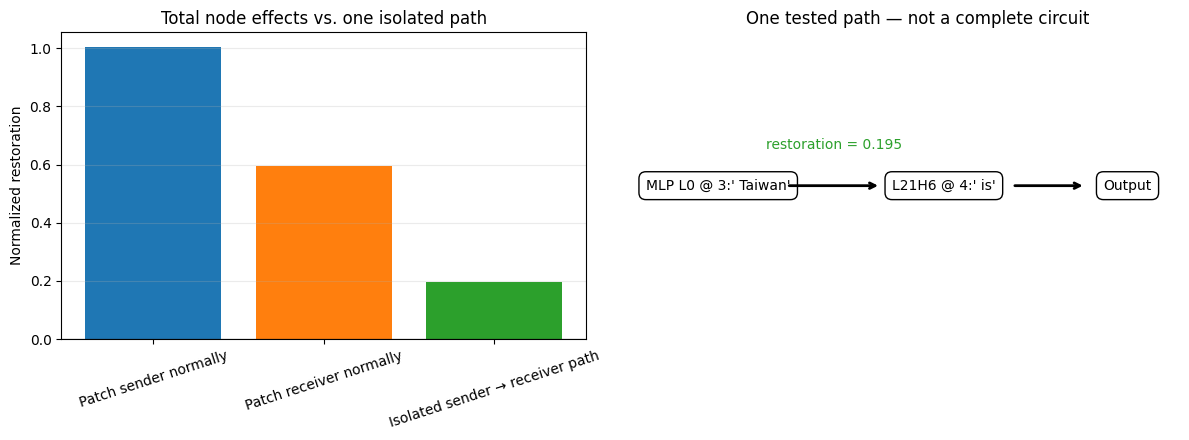

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(
    path_results["Intervention"],
    path_results["Normalized restoration"],
    color=["tab:blue", "tab:orange", "tab:green"],
)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Normalized restoration")
axes[0].set_title("Total node effects vs. one isolated path")
axes[0].tick_params(axis="x", rotation=18)
axes[0].grid(axis="y", alpha=0.25)

axes[1].axis("off")
box = dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black")
axes[1].text(0.12, 0.5, sender["Label"], ha="center", va="center", bbox=box)
axes[1].text(0.55, 0.5, receiver["Label"], ha="center", va="center", bbox=box)
axes[1].text(0.9, 0.5, "Output", ha="center", va="center", bbox=box)
axes[1].annotate("", xy=(0.43, 0.5), xytext=(0.25, 0.5), arrowprops=dict(arrowstyle="->", lw=2))
axes[1].annotate("", xy=(0.82, 0.5), xytext=(0.68, 0.5), arrowprops=dict(arrowstyle="->", lw=2))
axes[1].text(
    0.34,
    0.62,
    f"restoration = {path_restoration:.3f}",
    ha="center",
    color="tab:green",
)
axes[1].set_title("One tested path — not a complete circuit")

fig.tight_layout()
plt.show()

## 7. Approximate the same paths with gradients

True Path Patching gives direct intervention evidence, but testing every possible sender → receiver route requires many forward passes. **Edge Attribution Patching (EAP)** uses a first-order approximation to rank those routes more cheaply:

\[
\text{Edge Effect}(s \rightarrow r)
\approx
\nabla_{z_r} M
\cdot
\left(a_{s,\text{clean}}-a_{s,\text{corrupted}}\right)
\]

Here, \(s\) is a sender, \(r\) is a receiver, \(a_s\) is the sender contribution entering the receiver, \(z_r\) is the receiver input, and \(M\) is our logit-difference metric.

For the selected attention head, the country-token sender reaches the head through its **key and value inputs**. One backward pass gives the relevant receiver-input gradients. We use them to estimate every upstream MLP → selected attention-head route, then run the corresponding true Path Patching interventions so we can compare the approximation with what actually happens.

This remains a small teaching example: we search one family of edges into one receiver, not the model's complete circuit.

In [10]:
sender_candidates = (
    true_df[
        (true_df["Component"] == "MLP")
        & (true_df["Position"] == COUNTRY_POSITION)
        & (true_df["Layer"] < receiver_layer)
    ]
    .sort_values("Layer")
    .copy()
)


def run_isolated_path(sender_row):
    sender_layer_i = int(sender_row["Layer"])
    sender_hook_i = sender_row["Hook name"]
    frozen_hooks = [
        name
        for name in candidate_hook_names
        if sender_layer_i < hook_layer(name) < receiver_layer
    ]
    isolated_receiver = {}

    def patch_sender_i(activation, hook):
        activation[:, COUNTRY_POSITION, :] = clean_cache[sender_hook_i][
            :, COUNTRY_POSITION, :
        ]
        return activation

    def freeze_i(activation, hook):
        return corrupted_component_cache[hook.name]

    def capture_receiver_i(activation, hook):
        isolated_receiver["activation"] = activation[
            :, FINAL_POSITION, receiver_head, :
        ].detach().clone()
        return activation

    hooks = [(sender_hook_i, patch_sender_i)]
    hooks += [(name, freeze_i) for name in frozen_hooks]
    hooks += [(receiver_hook, capture_receiver_i)]

    with torch.inference_mode():
        model.run_with_hooks(corrupted_tokens, fwd_hooks=hooks)

    def patch_receiver_i(activation, hook):
        activation[:, FINAL_POSITION, receiver_head, :] = isolated_receiver[
            "activation"
        ]
        return activation

    with torch.inference_mode():
        logits = model.run_with_hooks(
            corrupted_tokens,
            fwd_hooks=[(receiver_hook, patch_receiver_i)],
        )

    return metric_tensor(logits).item() - corrupted_metric


receiver_input_hooks = {
    "key": f"blocks.{receiver_layer}.hook_k_input",
    "value": f"blocks.{receiver_layer}.hook_v_input",
}
edge_cache = {}
model.reset_hooks()
model.zero_grad(set_to_none=True)
model.add_caching_hooks(
    names_filter=lambda name: name in receiver_input_hooks.values(),
    incl_bwd=True,
    cache=edge_cache,
)

eap_start = time.perf_counter()
gradient_logits = model(corrupted_tokens)
metric_tensor(gradient_logits).backward()
eap_seconds = time.perf_counter() - eap_start
model.reset_hooks()
model.zero_grad(set_to_none=True)

receiver_gradient = sum(
    edge_cache[f"{hook_name}_grad"][:, COUNTRY_POSITION, receiver_head, :]
    for hook_name in receiver_input_hooks.values()
)

path_rows = []
path_sweep_start = time.perf_counter()
for _, sender_candidate in sender_candidates.iterrows():
    sender_hook_i = sender_candidate["Hook name"]
    sender_delta = (
        clean_cache[sender_hook_i][:, COUNTRY_POSITION, :]
        - corrupted_component_cache[sender_hook_i][:, COUNTRY_POSITION, :]
    )
    eap_effect = (sender_delta * receiver_gradient).sum().item()
    true_effect = run_isolated_path(sender_candidate)
    path_rows.append(
        {
            "Edge": f"{sender_candidate['Label']} → {receiver['Label']}",
            "Sender layer": int(sender_candidate["Layer"]),
            "True path effect": true_effect,
            "EAP estimate": eap_effect,
            "True restoration": true_effect / metric_gap,
            "EAP restoration": eap_effect / metric_gap,
        }
    )

path_sweep_seconds = time.perf_counter() - path_sweep_start
edge_df = pd.DataFrame(path_rows)

selected_edge = edge_df[edge_df["Sender layer"] == sender_layer].iloc[0]
assert np.isclose(selected_edge["True restoration"], path_restoration, atol=1e-5)

print(f"Receiver: {receiver['Label']}")
print(f"Candidate MLP → receiver paths: {len(edge_df)}")
print(f"One EAP forward/backward pass: {eap_seconds:.2f} seconds")
print(f"True Path Patching sweep: {path_sweep_seconds:.2f} seconds")
display(
    edge_df.reindex(edge_df["True restoration"].abs().sort_values(ascending=False).index)
    .head(12)
    .round(3)
)

Receiver: L21H6 @ 4:' is'
Candidate MLP → receiver paths: 21
One EAP forward/backward pass: 0.39 seconds
True Path Patching sweep: 3.62 seconds


,Edge,Sender layer,True path effect,EAP estimate,True restoration,EAP restoration
0,MLP L0 @ 3:' Taiwan' → L21H6 @ 4:' is',0,2.551,2.425,0.195,0.185
16,MLP L16 @ 3:' Taiwan' → L21H6 @ 4:' is',16,1.144,1.108,0.087,0.084
4,MLP L4 @ 3:' Taiwan' → L21H6 @ 4:' is',4,1.095,0.977,0.083,0.075
5,MLP L5 @ 3:' Taiwan' → L21H6 @ 4:' is',5,0.967,0.942,0.074,0.072
3,MLP L3 @ 3:' Taiwan' → L21H6 @ 4:' is',3,0.314,0.298,0.024,0.023
19,MLP L19 @ 3:' Taiwan' → L21H6 @ 4:' is',19,0.278,0.224,0.021,0.017
2,MLP L2 @ 3:' Taiwan' → L21H6 @ 4:' is',2,0.269,0.253,0.021,0.019
15,MLP L15 @ 3:' Taiwan' → L21H6 @ 4:' is',15,0.242,0.230,0.018,0.018
13,MLP L13 @ 3:' Taiwan' → L21H6 @ 4:' is',13,0.145,0.137,0.011,0.010
20,MLP L20 @ 3:' Taiwan' → L21H6 @ 4:' is',20,0.141,-0.036,0.011,-0.003


## 8. Compare EAP with true Path Patching

The comparison asks two separate questions:

1. Does the approximation rank the important sender → receiver routes similarly?
2. Does it estimate their effect sizes accurately?

A high correlation can make EAP useful for candidate search even when individual effect estimates are imperfect. The true interventions remain the stronger evidence.

In [11]:
pearson = edge_df["True restoration"].corr(edge_df["EAP restoration"])
spearman = edge_df["True restoration"].rank().corr(edge_df["EAP restoration"].rank())

timing_df = pd.DataFrame(
    {
        "Method": [
            f"{len(edge_df)} true Path Patching interventions",
            "One EAP forward/backward pass",
        ],
        "Seconds": [path_sweep_seconds, eap_seconds],
    }
)

print(f"Pearson correlation:  {pearson:.3f}")
print(f"Spearman correlation: {spearman:.3f}")
display(timing_df.round(2))

Pearson correlation:  0.998
Spearman correlation: 0.964


,Method,Seconds
0,21 true Path Patching interventions,3.62
1,One EAP forward/backward pass,0.39


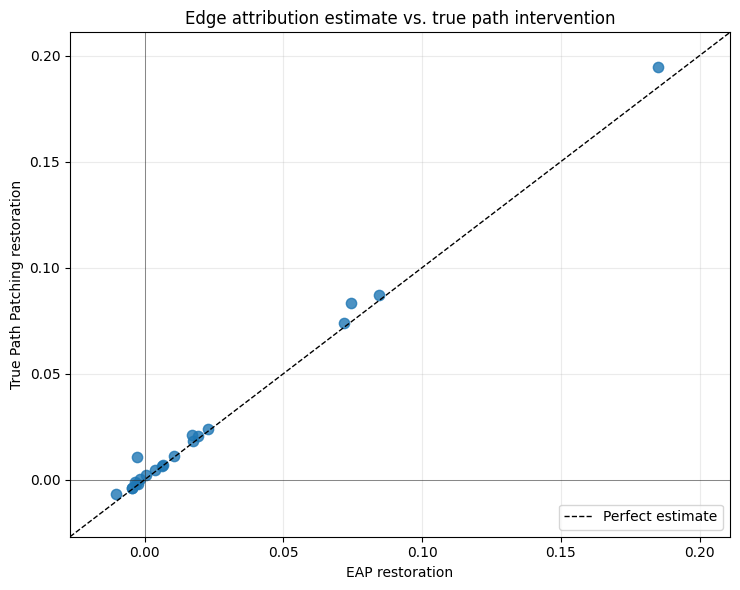

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 6))

ax.scatter(
    edge_df["EAP restoration"],
    edge_df["True restoration"],
    s=55,
    alpha=0.8,
)

limits = [
    min(edge_df["EAP restoration"].min(), edge_df["True restoration"].min()),
    max(edge_df["EAP restoration"].max(), edge_df["True restoration"].max()),
]
padding = 0.08 * max(limits[1] - limits[0], 1e-6)
limits = [limits[0] - padding, limits[1] + padding]

ax.plot(limits, limits, "k--", linewidth=1, label="Perfect estimate")
ax.axhline(0, color="black", linewidth=0.6, alpha=0.5)
ax.axvline(0, color="black", linewidth=0.6, alpha=0.5)
ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_xlabel("EAP restoration")
ax.set_ylabel("True Path Patching restoration")
ax.set_title("Edge attribution estimate vs. true path intervention")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

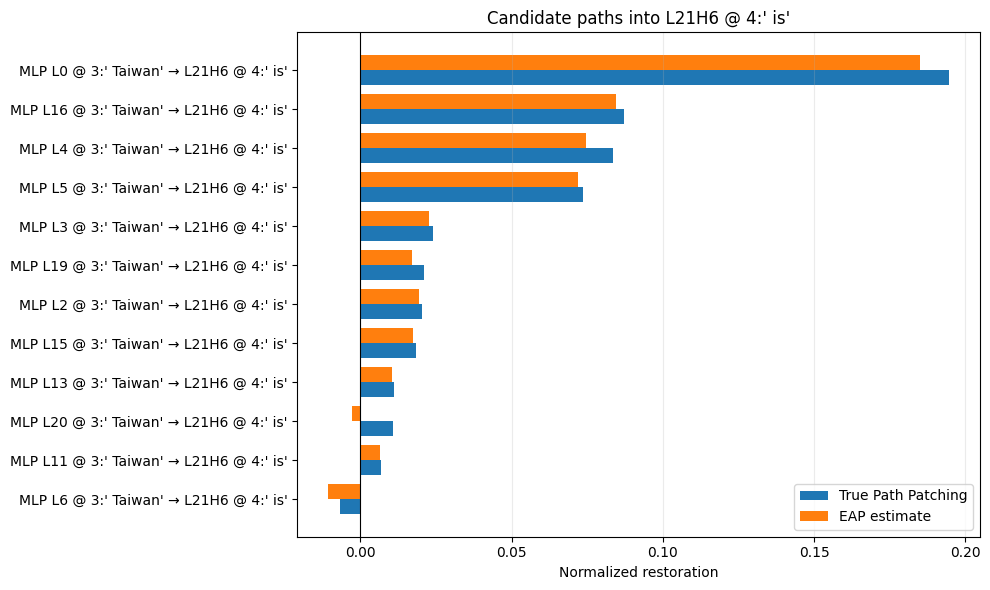

In [13]:
top_edges = edge_df.reindex(
    edge_df["True restoration"].abs().sort_values(ascending=False).index
).head(12)

y = np.arange(len(top_edges))
height = 0.38

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    y + height / 2,
    top_edges["True restoration"],
    height,
    label="True Path Patching",
)
ax.barh(
    y - height / 2,
    top_edges["EAP restoration"],
    height,
    label="EAP estimate",
)
ax.set_yticks(y)
ax.set_yticklabels(top_edges["Edge"])
ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Normalized restoration")
ax.set_title(f"Candidate paths into {receiver['Label']}")
ax.legend()
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

## 9. Inspect approximation failures

EAP is a local, first-order approximation. A large intervention can move the model into a region where the linear estimate is inaccurate, and interactions between key and value pathways can also be nonlinear.

The table below sorts candidate paths by absolute disagreement. These are exactly the cases where candidate search should be followed by a real intervention rather than treated as a conclusion.

In [14]:
edge_df["Absolute error"] = (
    edge_df["True restoration"] - edge_df["EAP restoration"]
).abs()

display(
    edge_df.sort_values("Absolute error", ascending=False)[
        [
            "Edge",
            "True restoration",
            "EAP restoration",
            "Absolute error",
        ]
    ]
    .head(12)
    .round(3)
)

,Edge,True restoration,EAP restoration,Absolute error
20,MLP L20 @ 3:' Taiwan' → L21H6 @ 4:' is',0.011,-0.003,0.013
0,MLP L0 @ 3:' Taiwan' → L21H6 @ 4:' is',0.195,0.185,0.010
4,MLP L4 @ 3:' Taiwan' → L21H6 @ 4:' is',0.083,0.075,0.009
19,MLP L19 @ 3:' Taiwan' → L21H6 @ 4:' is',0.021,0.017,0.004
6,MLP L6 @ 3:' Taiwan' → L21H6 @ 4:' is',-0.007,-0.010,0.004
16,MLP L16 @ 3:' Taiwan' → L21H6 @ 4:' is',0.087,0.084,0.003
17,MLP L17 @ 3:' Taiwan' → L21H6 @ 4:' is',-0.001,-0.003,0.002
5,MLP L5 @ 3:' Taiwan' → L21H6 @ 4:' is',0.074,0.072,0.002
7,MLP L7 @ 3:' Taiwan' → L21H6 @ 4:' is',0.000,-0.002,0.002
18,MLP L18 @ 3:' Taiwan' → L21H6 @ 4:' is',0.002,0.000,0.002


## 10. From one path to a circuit

This notebook first uses component-level **nodes** to choose endpoints, then performs real Path Patching on specified sender → receiver routes. Each tested path is evidence about one interaction, not a complete circuit.

| Method in this notebook/article | What is scored or replaced? | Evidence |
| --- | --- | --- |
| Node activation patching | One component output | Real intervention used to choose endpoints |
| Path Patching | A controlled sender → receiver route | Real intervention |
| Edge Attribution Patching | One sender → receiver contribution | First-order approximation |

EAP can rank many graph edges and produce a candidate sparse subgraph. It does not by itself prove that the selected edges form a faithful or human-understandable circuit; important candidates still need intervention-based validation.

The practical workflow is:

1. use EAP to rank candidate edges cheaply;
2. verify important routes with true Path Patching.

Attribution helps us search; intervention provides stronger causal evidence.

## 11. Try another search

1. Choose another downstream attention head as the receiver.
2. Add upstream attention heads to the sender candidates.
3. Score the key and value routes separately instead of summing them.
4. Compare the top EAP-ranked edges with the top true Path Patching effects.
5. Inspect paths with small EAP scores but large true effects.
6. Track one answer logit instead of the `Tokyo − Taipei` difference.